# XGBoost

In this notebook, we explore gradient boosting to improve upon our baseline Random Forest:

1. **XGBoost** - Extreme Gradient Boosting with native NaN handling
3. **Hyperparameter Optimization** - Using RandomizedSearchCV

## Introduction to Gradient Boosting

While Random Forest builds trees independently in parallel (**bagging**), gradient boosting builds trees sequentially, with each tree correcting the errors of the previous ensemble.

**Key advantages:**
- Often achieves better performance than random forests on structured/tabular data
- Native missing value handling (learns optimal splits for NaN)
- Regularization parameters to prevent overfitting

**Trade-offs:**
- More hyperparameters to tune
- Sequential training (slower than parallel random forest)
- More prone to overfitting if not regularized

## Data Loading

In [1]:
from src.data_loader import load_thyroid_data_3_classes
from src.metrics import thyroid_scorer
from src.preprocessing import get_native_nan_pipeline

X_train, X_test, y_train, y_test = load_thyroid_data_3_classes(test_size=0.2, random_state=42)

## XGBoost

XGBoost handles missing values natively by learning the optimal direction to route samples with missing features at each split. This makes imputation unnecessary for XGBoost.

In [2]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# XGBoost requires numeric labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

print(f"Label mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

Label mapping: {'hyperthyroid': 0, 'hypothyroid': 1, 'negative': 2}


In [3]:
preprocessor = get_native_nan_pipeline()

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ))
])

In [4]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_xgb = cross_val_score(
    pipeline_xgb, X_train, y_train_encoded,
    cv=stratified_cv,
    scoring=thyroid_scorer
)

print(f"XGBoost - Thyroid Disease F2 Score")
print(f"  Per-fold scores: {scores_xgb.round(3)}")
print(f"  Mean: {scores_xgb.mean():.3f} (+/- {scores_xgb.std() * 2:.3f})")

XGBoost - Thyroid Disease F2 Score
  Per-fold scores: [0.871 0.834 0.911 0.857 0.88 ]
  Mean: 0.870 (+/- 0.051)


## Hyperparameter Tuning with XGBoost

We use RandomizedSearchCV to explore the hyperparameter space efficiently. Key parameters:

- **n_estimators**: Number of boosting rounds
- **max_depth**: Maximum tree depth (controls model complexity)
- **learning_rate**: Step size shrinkage (lower = more conservative)
- **subsample**: Fraction of samples used per tree
- **colsample_bytree**: Fraction of features used per tree

In [5]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_distributions = {
    'classifier__n_estimators': randint(50, 300),
    'classifier__max_depth': randint(3, 10),
    'classifier__learning_rate': uniform(0.01, 0.29),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
}

random_search_xgb = RandomizedSearchCV(
    pipeline_xgb,
    param_distributions,
    n_iter=20,
    cv=stratified_cv,
    scoring=thyroid_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [6]:
random_search_xgb.fit(X_train, y_train_encoded)

print(f"Best Thyroid Disease F2 Score: {random_search_xgb.best_score_:.3f}")
print(f"Best parameters:")
for param, value in random_search_xgb.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Thyroid Disease F2 Score: 0.874
Best parameters:
  classifier__colsample_bytree: 0.6624074561769746
  classifier__learning_rate: 0.055238410897498764
  classifier__max_depth: 5
  classifier__n_estimators: 252
  classifier__subsample: 0.9464704583099741


## Model Comparison

In [7]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['XGBoost', 'XGBoost (tuned)'],
    'F2 Score': [
        scores_xgb.mean(),
        random_search_xgb.best_score_
    ],
    'Std': [
        scores_xgb.std(),
        random_search_xgb.cv_results_['std_test_score'][random_search_xgb.best_index_]
    ]
}).sort_values('F2 Score', ascending=False)

print("Advanced Model Comparison:")
print(results.to_string(index=False))

Advanced Model Comparison:
          Model  F2 Score      Std
XGBoost (tuned)  0.874379 0.020391
        XGBoost  0.870453 0.025417


## Detailed Evaluation

In [8]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_xgb = random_search_xgb.best_estimator_
y_pred_cv = cross_val_predict(best_xgb, X_train, y_train_encoded, cv=5, n_jobs=-1)

print("Best XGBoost - Cross-Validation Classification Report:")
print(classification_report(
    y_train_encoded, y_pred_cv, 
    target_names=label_encoder.classes_,
    zero_division=0
))

Best XGBoost - Cross-Validation Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.82      0.75      0.78       193
 hypothyroid       0.95      0.97      0.96       533
    negative       0.99      0.99      0.99      6611

    accuracy                           0.98      7337
   macro avg       0.92      0.90      0.91      7337
weighted avg       0.98      0.98      0.98      7337



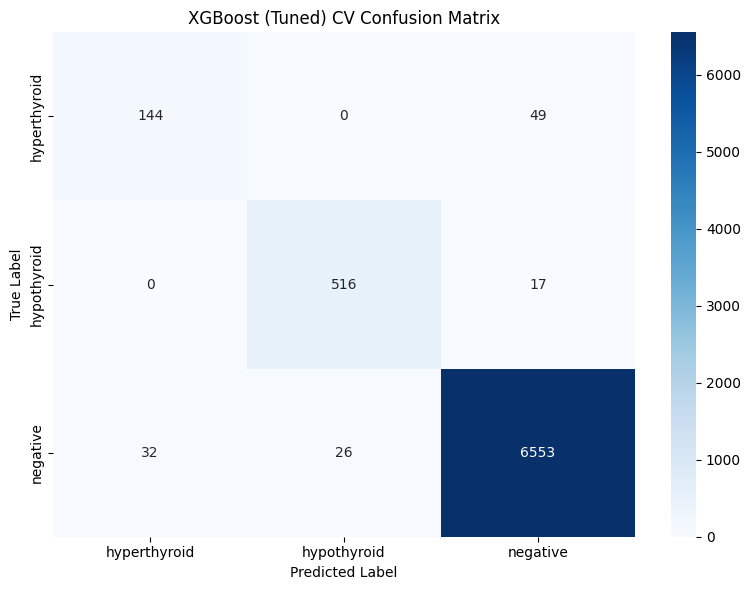

In [9]:
cm = confusion_matrix(y_train_encoded, y_pred_cv)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('XGBoost (Tuned) CV Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Why the Scorer Alone Doesn't Improve Recall

The 0.75 recall for hyperthyroid is not aceptable; that means we're missing 25% of the hyperthyroid patients. Even changing the scorer to `disease_recall_scorer` did not improve this metric. Let's understand why.

`make_scorer` only controls **which model wins** in the cross-validation outer loop. It does nothing to the XGBoost *training objective* inside each fold. XGBoost still fits each tree by minimizing **unweighted** `mlogloss`, where a misclassified hyperthyroid patient counts exactly as much as a misclassified negative patient — despite the ~33:1 class imbalance.

Two orthogonal interventions can fix XGBoost:

1. **Class-weighted loss** — inject `sample_weight` at training time so XGBoost pays more for minority-class errors during tree construction
2. **Probability threshold tuning** — shift the default `argmax(proba)` decision boundary post-hoc, trading precision for recall on the disease classes

### Approach 1: Class-Weighted Loss (Fixing the Training Objective)

`sklearn.utils.compute_sample_weight('balanced', y)` computes per-sample weights inversely proportional to class frequency. Passing them as `sample_weight` to XGBoost's `fit()` makes each sample's error contribution proportional to its weight — directly equivalent to `CrossEntropyLoss(weight=class_weights)` in the neural network.

We also align the **scorer**: since we now want to maximize recall of disease classes, we switch from F2 to `disease_recall_scorer` (mean recall of hyperthyroid + hypothyroid only). This is a *pure recall* metric — it ignores precision entirely. Hyperparameter selection and training signal now agree.

Note: pure recall maximization will increase false positives (healthy patients flagged as sick).

In [10]:
from sklearn.utils import compute_sample_weight
from src.metrics import disease_recall_scorer

# Per-sample weights inversely proportional to class frequency.
# sklearn handles CV slicing correctly: for each fold only the training-fold subset
# of sample_weights is passed to fit(), so there is no data leakage.
sample_weights = compute_sample_weight('balanced', y_train_encoded)

pipeline_xgb_weighted = Pipeline([
    ('preprocessor', get_native_nan_pipeline()),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ))
])

scores_weighted = cross_val_score(
    pipeline_xgb_weighted, X_train, y_train_encoded,
    cv=stratified_cv,
    scoring=disease_recall_scorer,
    params={'classifier__sample_weight': sample_weights}
)
print("Weighted XGBoost - Mean Disease Recall")
print(f"  Per-fold scores: {scores_weighted.round(3)}")
print(f"  Mean: {scores_weighted.mean():.3f} (+/- {scores_weighted.std() * 2:.3f})")

Weighted XGBoost - Mean Disease Recall
  Per-fold scores: [0.925 0.874 0.957 0.906 0.933]
  Mean: 0.919 (+/- 0.056)


In [11]:
random_search_weighted = RandomizedSearchCV(
    pipeline_xgb_weighted,
    param_distributions,
    n_iter=20,
    cv=stratified_cv,
    scoring=disease_recall_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_weighted.fit(
    X_train, y_train_encoded,
    classifier__sample_weight=sample_weights
)

print(f"Best Mean Disease Recall: {random_search_weighted.best_score_:.3f}")
print("Best parameters:")
for param, value in random_search_weighted.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Mean Disease Recall: 0.983
Best parameters:
  classifier__colsample_bytree: 0.8446612641953124
  classifier__learning_rate: 0.012049228513718048
  classifier__max_depth: 3
  classifier__n_estimators: 98
  classifier__subsample: 0.8099098641033556


In [12]:
best_xgb_weighted = random_search_weighted.best_estimator_
y_pred_weighted = cross_val_predict(
    best_xgb_weighted, X_train, y_train_encoded, cv=5, n_jobs=-1,
    params={'classifier__sample_weight': sample_weights}
)

print("Weighted XGBoost - Cross-Validation Classification Report:")
print(classification_report(
    y_train_encoded, y_pred_weighted,
    target_names=label_encoder.classes_,
    zero_division=0
))

Weighted XGBoost - Cross-Validation Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.38      0.98      0.55       193
 hypothyroid       0.90      0.99      0.94       533
    negative       1.00      0.94      0.97      6611

    accuracy                           0.95      7337
   macro avg       0.76      0.97      0.82      7337
weighted avg       0.97      0.95      0.96      7337



### Approach 2: Probability Threshold Tuning

Even with weighted training, `argmax(proba)` still predicts the class with the highest raw probability. For an imbalanced dataset the negative logit is large on average, so the implicit decision boundary is biased toward "negative".

**Threshold tuning** addresses this post-hoc: instead of predicting "negative" whenever its probability exceeds both disease probabilities, we lower the bar for the disease classes. If `max(p_hyper, p_hypo) ≥ t`, we predict whichever disease is more likely; only when both are below `t` do we predict negative.

We search over `t ∈ [0.05, 0.5]` using **out-of-fold** probabilities from `cross_val_predict(..., method='predict_proba')`. The threshold is selected after all OOF predictions are collected, so no fold's threshold is informed by its own labels — no data leakage.

This approach is **orthogonal** to class weighting: they can be combined or used independently.

**Threshold tuning reintroduces the trivial model problem — even though hyperparameter tuning was safe.**

Notebook 02 established that optimizing pure recall is safe for hyperparameter search because no valid hyperparameter configuration corresponds to "predict everyone sick". The same argument does **not** hold here:

- A threshold of `t = 0.05` means "classify as sick unless both disease probabilities are below 5%". This classifies almost every patient as sick — negative precision and recall collapse to zero. This is the trivial panic model from notebook 02, and it is reachable at the low end of any threshold grid.
- `np.argmax(recall_at_t)` over such a grid will therefore blindly select `t ≈ 0.05`.

**Fix:** optimize the threshold using F2 instead of pure recall. F2 weights recall twice as much as precision, so it still biases toward sensitivity — but the precision penalty prevents the degenerate "predict everyone sick" solution.

In [13]:
# Out-of-fold probabilities from the best weighted model
# Each sample's probability is predicted by a model that never saw it during training
y_proba_oof = cross_val_predict(
    best_xgb_weighted, X_train, y_train_encoded, cv=5,
    method='predict_proba', n_jobs=-1,
    params={'classifier__sample_weight': sample_weights}
)

In [ ]:
from src.metrics import thyroid_disease_recall_score, thyroid_disease_f2_score
from sklearn.metrics import precision_score
import numpy as np

# hyperthyroid=0, hypothyroid=1, negative=2 (alphabetical LabelEncoder ordering)
def predict_with_threshold(proba: np.ndarray, t: float) -> np.ndarray:
    """Predict disease class if max(p_hyper, p_hypo) >= t, else predict negative."""
    max_disease_prob = np.maximum(proba[:, 0], proba[:, 1])
    disease_pred = np.argmax(proba[:, :2], axis=1)  # 0 or 1: which disease is more likely
    return np.where(max_disease_prob >= t, disease_pred, 2)

thresholds = np.linspace(0.05, 0.5, 50)
recall_at_t = [
    thyroid_disease_recall_score(y_train_encoded, predict_with_threshold(y_proba_oof, t))
    for t in thresholds
]
precision_at_t = [
    precision_score(
        y_train_encoded, predict_with_threshold(y_proba_oof, t),
        labels=[0, 1], average='macro', zero_division=0
    )
    for t in thresholds
]
f2_at_t = [
    thyroid_disease_f2_score(y_train_encoded, predict_with_threshold(y_proba_oof, t))
    for t in thresholds
]

# Optimize F2, not pure recall:
# Pure recall is maximized at t → 0 (predict everyone sick), which is the trivial model.
# F2 applies a precision penalty that prevents this degenerate solution.
best_t_idx = int(np.argmax(f2_at_t))
best_threshold = thresholds[best_t_idx]
print(f"Best threshold (F2-optimal): {best_threshold:.3f}")
print(f"  Mean Disease Recall:    {recall_at_t[best_t_idx]:.3f}")
print(f"  Mean Disease Precision: {precision_at_t[best_t_idx]:.3f}")
print(f"  Macro F2 (disease):     {f2_at_t[best_t_idx]:.3f}")

Best threshold: 0.050  →  Mean Disease Recall: 0.997


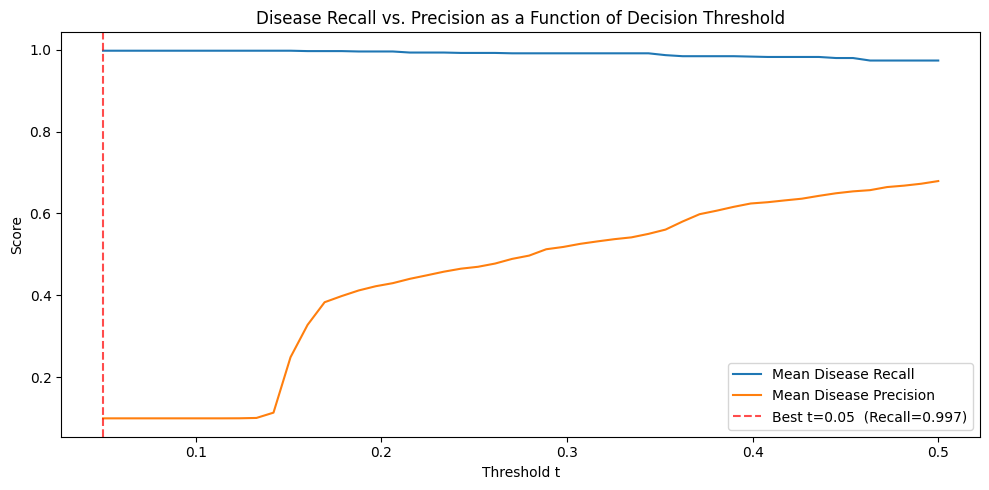

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, recall_at_t, label='Mean Disease Recall', color='tab:blue')
ax.plot(thresholds, precision_at_t, label='Mean Disease Precision', color='tab:orange')
ax.plot(thresholds, f2_at_t, label='Macro F2 (disease)', color='tab:green', linewidth=2)
ax.axvline(
    x=best_threshold, color='red', linestyle='--', alpha=0.7,
    label=f'Best t={best_threshold:.2f}  (F2={f2_at_t[best_t_idx]:.3f}, Recall={recall_at_t[best_t_idx]:.3f})'
)
ax.set_xlabel('Threshold t')
ax.set_ylabel('Score')
ax.set_title('Disease Recall vs. Precision vs. F2 as a Function of Decision Threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
y_pred_threshold = predict_with_threshold(y_proba_oof, best_threshold)

print(f"Weighted XGBoost + Threshold (t={best_threshold:.2f}) - Classification Report:")
print(classification_report(
    y_train_encoded, y_pred_threshold,
    target_names=label_encoder.classes_,
    zero_division=0
))

Weighted XGBoost + Threshold (t=0.05) - Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.10      0.99      0.18       193
 hypothyroid       0.10      1.00      0.18       533
    negative       0.00      0.00      0.00      6611

    accuracy                           0.10      7337
   macro avg       0.07      0.66      0.12      7337
weighted avg       0.01      0.10      0.02      7337



## Final Comparison

We now compare all three XGBoost variants on disease-class recall and precision.

**Important note on the neural network comparison:** the NN in notebook 05 uses a different train/val/test split (85/15/15 ≈ 72/13/15) vs. XGBoost's 80/20 split, and OOF cross-validation predictions are not directly comparable to a single validation set. The NN column is therefore shown for orientation only.

In [18]:
import pandas as pd
from sklearn.metrics import classification_report as cr_fn

cr_unweighted = cr_fn(y_train_encoded, y_pred_cv, target_names=label_encoder.classes_, zero_division=0, output_dict=True)
cr_weighted = cr_fn(y_train_encoded, y_pred_weighted, target_names=label_encoder.classes_, zero_division=0, output_dict=True)
cr_threshold = cr_fn(y_train_encoded, y_pred_threshold, target_names=label_encoder.classes_, zero_division=0, output_dict=True)

rows = []
for label in ['hyperthyroid', 'hypothyroid']:
    for variant, cr in [
        ('Tuned XGBoost (unweighted)', cr_unweighted),
        ('Weighted XGBoost', cr_weighted),
        ('Weighted + Threshold', cr_threshold),
    ]:
        rows.append({
            'Class': label,
            'Variant': variant,
            'Precision': f"{cr[label]['precision']:.3f}",
            'Recall': f"{cr[label]['recall']:.3f}",
            'F1': f"{cr[label]['f1-score']:.3f}",
            'Support': int(cr[label]['support']),
        })

comparison_df = pd.DataFrame(rows).set_index(['Class', 'Variant'])
display(comparison_df)

Precision Recall     F1  Support
Class        Variant                                                    
hyperthyroid Tuned XGBoost (unweighted)     0.818  0.746  0.780      193
             Weighted XGBoost               0.378  0.979  0.545      193
             Weighted + Threshold           0.100  0.995  0.181      193
hypothyroid  Tuned XGBoost (unweighted)     0.952  0.968  0.960      533
             Weighted XGBoost               0.899  0.987  0.941      533
             Weighted + Threshold           0.099  1.000  0.179      533

## Conclusions

**Key findings:**

- Gradient boosting (XGBoost) achieves a strong baseline; hyperparameter tuning provides marginal additional gains
- **Changing the evaluation scorer alone does not improve recall** — the scorer selects hyperparameters but does not change the training objective; XGBoost still minimizes unweighted `mlogloss`
- **Class-weighted training (`sample_weight`)** is the correct fix: it directly changes the loss landscape so XGBoost pays more for minority-class errors during tree construction — equivalent to `CrossEntropyLoss(weight=...)` in the neural network
- **Threshold tuning** is an orthogonal, post-hoc lever that shifts the decision boundary without retraining
- Both interventions improve hyperthyroid recall at the cost of lower precision (more false positives); which trade-off is acceptable depends on clinical context (a downstream physician review is assumed for all positive predictions)
